In [55]:
import pandas as pd
import os, re, glob, shutil

In [56]:
current_dir = os.getcwd()
start_kit_dir = current_dir + '/start_kit'

Load the `json` into DataFrame.

In [58]:
json_dir = start_kit_dir +'/WLASL_v0.3.json'

df = pd.read_json(json_dir)
df_exploded = df.explode("instances", ignore_index=True)
df_flat = pd.concat(
    [df_exploded.drop(columns=["instances"]),
     pd.json_normalize(df_exploded["instances"])],
    axis=1
)
df_flat.head()

,gloss,bbox,fps,frame_end,frame_start,instance_id,signer_id,source,split,url,variation_id,video_id
0,book,"[385, 37, 885, 720]",25,-1,1,0,118,aslbrick,train,http://aslbricks.org/New/ASL-Videos/book.mp4,0,69241
1,book,"[190, 25, 489, 370]",25,-1,1,1,90,aslsignbank,train,https://aslsignbank.haskins.yale.edu/dictionar...,0,65225
2,book,"[262, 1, 652, 480]",25,-1,1,2,110,valencia-asl,train,https://www.youtube.com/watch?v=0UsjUE-TXns,0,68011
3,book,"[123, 19, 516, 358]",25,60,1,3,113,lillybauer,train,https://www.youtube.com/watch?v=1QOYOZ3g-aY,0,68208
4,book,"[95, 0, 1180, 720]",25,-1,1,4,109,valencia-asl,train,https://www.youtube.com/watch?v=aGtIHKEdCds,0,68012


In [59]:
df_flat.columns.to_list()

['gloss',
 'bbox',
 'fps',
 'frame_end',
 'frame_start',
 'instance_id',
 'signer_id',
 'source',
 'split',
 'url',
 'variation_id',
 'video_id']

### JSON - Data Analysis

In [60]:
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21083 entries, 0 to 21082
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   gloss         21083 non-null  object
 1   bbox          21083 non-null  object
 2   fps           21083 non-null  int64 
 3   frame_end     21083 non-null  int64 
 4   frame_start   21083 non-null  int64 
 5   instance_id   21083 non-null  int64 
 6   signer_id     21083 non-null  int64 
 7   source        21083 non-null  object
 8   split         21083 non-null  object
 9   url           21083 non-null  object
 10  variation_id  21083 non-null  int64 
 11  video_id      21083 non-null  object
dtypes: int64(6), object(6)
memory usage: 1.9+ MB


#### Q1: Find out the total number of videos in this dataset.

In [61]:
print(f"Total number of videos: {df_flat.shape[0]}")

Total number of videos: 21083


#### Q2: How many glosses are there in this dataset?

In [62]:
print(f"Total number of glosses: {df_flat['gloss'].unique().shape[0]}")

Total number of glosses: 2000


#### Q3: Which are the top-N most frequent gloss?

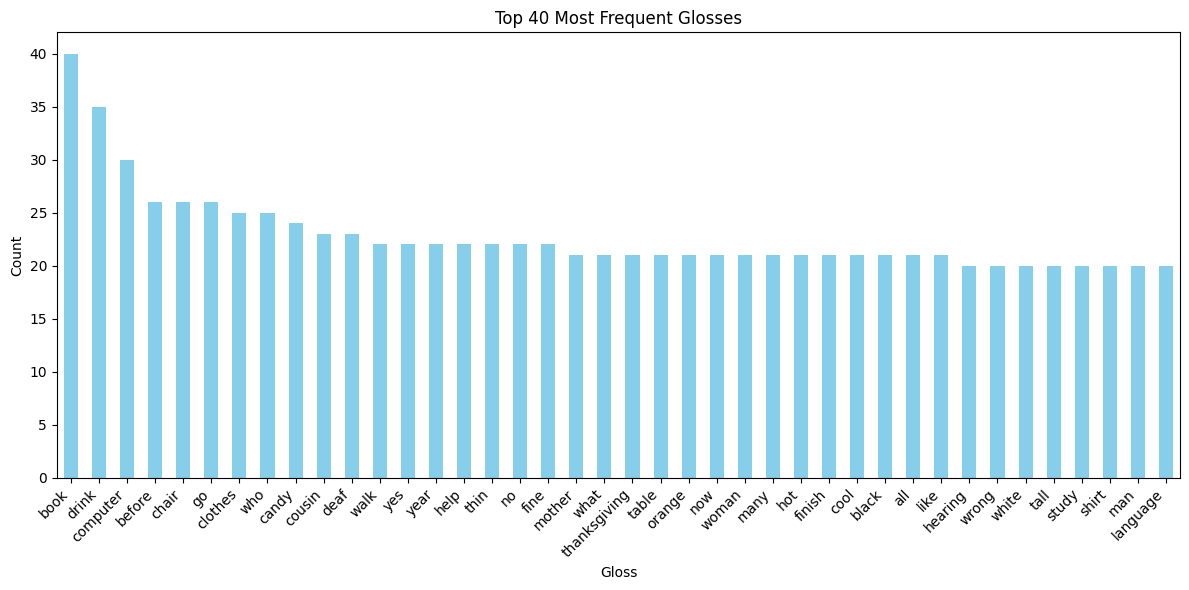

In [63]:
import matplotlib.pyplot as plt

gloss_counts = df_flat["gloss"].value_counts()

top_n = 40
gloss_counts.head(top_n).plot(kind="bar", figsize=(12,6), color="skyblue")
plt.title(f"Top {top_n} Most Frequent Glosses")
plt.xlabel("Gloss")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Q4: Which are the top-N least frequent gloss?

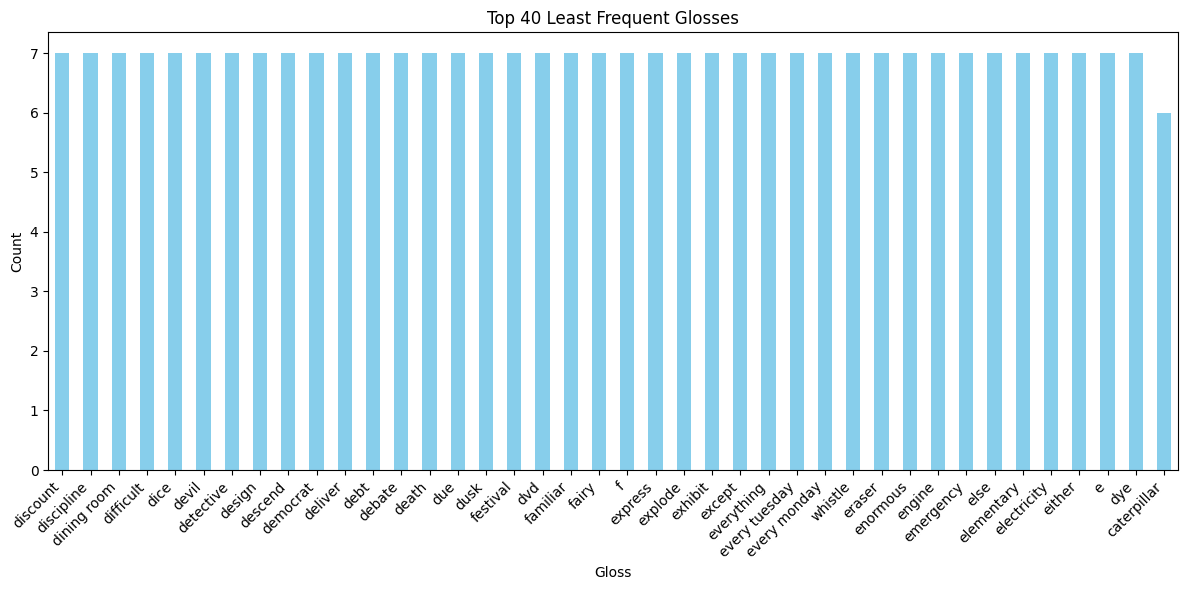

In [64]:
import matplotlib.pyplot as plt

gloss_counts = df_flat["gloss"].value_counts()

top_n = 40
gloss_counts.tail(top_n).plot(kind="bar", figsize=(12,6), color="skyblue")
plt.title(f"Top {top_n} Least Frequent Glosses")
plt.xlabel("Gloss")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [65]:
video_dir = start_kit_dir + '/raw_videos_mp4'
videos = glob.glob(os.path.join(video_dir, "*.mp4"))
print("Total number of videos: ", len(videos))

Total number of videos:  0
